<a href="https://colab.research.google.com/github/pauloricardo2-alt/lia1_2026_1/blob/main/Atividade_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Construir um modelo de Inteligência Artificial capaz de classificar imagens considerando 10 categorias: ['avião', 'automóvel', 'pássaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão'].
 Dada uma nova imagem de uma dessas categorias o modelo deve ser capaz de classificar e indicar o que é a imagem. <font color='red'>Lembrando: uma imagem é uma matriz de pixels!</font>


In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão do Python neste Notebook:', python_version())

Versão do Python neste Notebook: 3.12.13


In [2]:
# Instala o TF
#!pip install -q tensorflow==2.12
!pip install -q tensorflow


In [3]:
# Silencia mensagens do TF
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [4]:
# Imports
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
from PIL import Image
import os

## Carregando os dados - matéria prima
"https://cs.stanford.edu/~acoates/stl10"


In [5]:
# Carregando o STL-10
(ds_train, ds_test), ds_info = tfds.load(
    'stl10',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.5NESQS_1.0.0/stl10-test.tfrecord*...:   0%|          | 0/…

Generating unlabelled examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stl10/incomplete.5NESQS_1.0.0/stl10-unlabelled.tfrecord*...:   0%|        …

Dataset stl10 downloaded and prepared to /root/tensorflow_datasets/stl10/1.0.0. Subsequent calls will reuse this data.


In [6]:
# Nomes das classes oficiais do STL-10
nomes_classes = ['avião', 'pássaro', 'carro', 'gato', 'veado', 'cachorro', 'cavalo', 'macaco', 'navio', 'caminhão']

In [7]:
# Normaliza os valores dos pixels para que os dados fiquem na mesma escala
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [8]:
# Função para exibir as imagens
def visualiza_amostras(dataset, nomes_classes):
    plt.figure(figsize=(10, 10))
    # Pegamos um "batch" (lote) de imagens para mostrar
    for imagens, labels in dataset.take(1):
        for i in range(25):
            plt.subplot(5, 5, i + 1)
            plt.xticks([])
            plt.yticks([])
            plt.grid(False)
            plt.imshow(imagens[i])
            # No STL-10, o label vem como um número escalar
            plt.xlabel(nomes_classes[labels[i].numpy()])
    plt.show()


In [9]:
BATCH_SIZE = 32

train_data = ds_train.map(preprocess).batch(BATCH_SIZE)
test_data = ds_test.map(preprocess).batch(BATCH_SIZE)

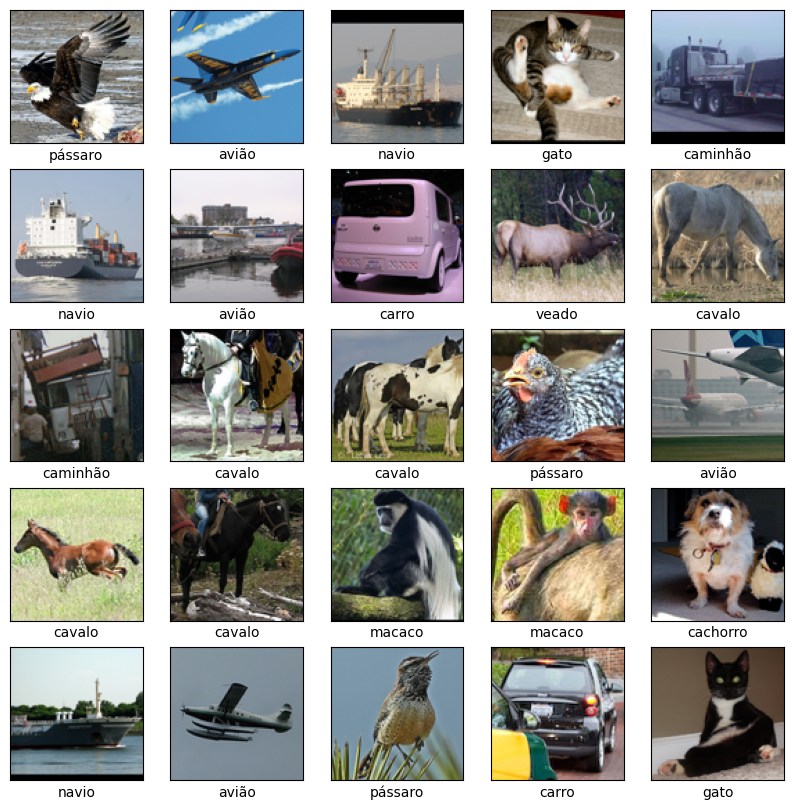

In [ ]:
# Executa a função
#Imagens de trino
visualiza_amostras(train_data, nomes_classes)

In [ ]:
#AGR que tem tudo, vai criar o modelo

## Construção do Modelo


In [10]:
#Tem 3 camadas por que é RGB# Arquitetura do Modelo -> Feature Learning

modelo_lia = models.Sequential([
    # 1. Feature Learning (O que você já tinha)
    layers.Input(shape=(96, 96, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2. Classification
    layers.Flatten(), # Transforma os (10, 10, 128) em um único vetor
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Segurança contra overfit
    layers.Dense(10, activation='softmax') # A saída de 10 classes
])

In [ ]:
#Vamo ver se a nossa aquitetura ta ok

In [11]:
# Sumário do modelo
modelo_lia.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,733,066 (6.61 MB)

 Trainable params: 1,733,066 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
#O deepseek tem 700 Bilhoes de parâmetros
#Vai usar a métrica de acurácia para ver o sucesso do modelo
#Não existe modelo com 100% e nem com 0%
#se ficar muito perto de 100%, desconfiar
#O olo humano da 70# em cancewr de pulmao, as IAs tem 90%
# Compilação do modelo
modelo_lia.compile(optimizer = 'adam',
                   loss = 'sparse_categorical_crossentropy',
                   metrics = ['accuracy'])

# adam - é um algoritmo de aprendizagem tipo backpropagation!
# loss - função de erro. Isso se resume a uma otimização função matemática!
# metrics - medir o sucesso!


In [14]:
#epochs é as temporadas, quantas vezes tem que passar por todo o dataset pra aperfeiçoar
#abaixo de 100 é brincadeira de criança

In [15]:
#Quanto mais ele roda, mais aprende, mais tem um momento em que ele começa a desaprender
#Ele desaptrnde por que pode começar a viciar e a tender
#Pode ser que o dataset seja desbalanceado, tipo 1000 de
#Overfit
%%time
history = modelo_lia.fit(train_data, epochs=100, validation_data=test_data)


modelo_lia.save('modelo_stl10_treinado.h5')
print("Modelo salvo com sucesso!")


Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.2838 - loss: 1.9149 - val_accuracy: 0.4234 - val_loss: 1.5393
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 148s 944ms/step - accuracy: 0.4256 - loss: 1.5123 - val_accuracy: 0.4711 - val_loss: 1.4243
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 148s 947ms/step - accuracy: 0.5048 - loss: 1.3278 - val_accuracy: 0.4885 - val_loss: 1.3663
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.5560 - loss: 1.1854 - val_accuracy: 0.5364 - val_loss: 1.2892
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.6210 - loss: 1.0496 - val_accuracy: 0.5326 - val_loss: 1.3461
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 151s 962ms/step - accuracy: 0.6774 - loss: 0.8998 - val_accuracy: 0.5008 - val_loss: 1.4599
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 153s 975ms/step - accuracy: 0.7158 - loss: 0.7848 - val_accuracy: 0.5238 - val_loss: 1.5052
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 157s 999ms/step - accuracy: 0.7476 - 

Modelo salvo com sucesso!
CPU times: user 6h 19min 52s, sys: 30min 2s, total: 6h 49min 54s
Wall time: 4h 39min 39s


## Avaliação do modelo

In [16]:
# Avaliação do modelo
erro_teste, acc_teste = modelo_lia.evaluate(test_data, verbose=2)

print(f'\nAcurácia no conjunto de teste: {acc_teste:.2%}')


250/250 - 51s - 204ms/step - accuracy: 0.5502 - loss: 4.6968

Acurácia no conjunto de teste: 55.02%


In [17]:
print('\nAcurácia com dados de Teste:', acc_teste)


Acurácia com dados de Teste: 0.5502499938011169


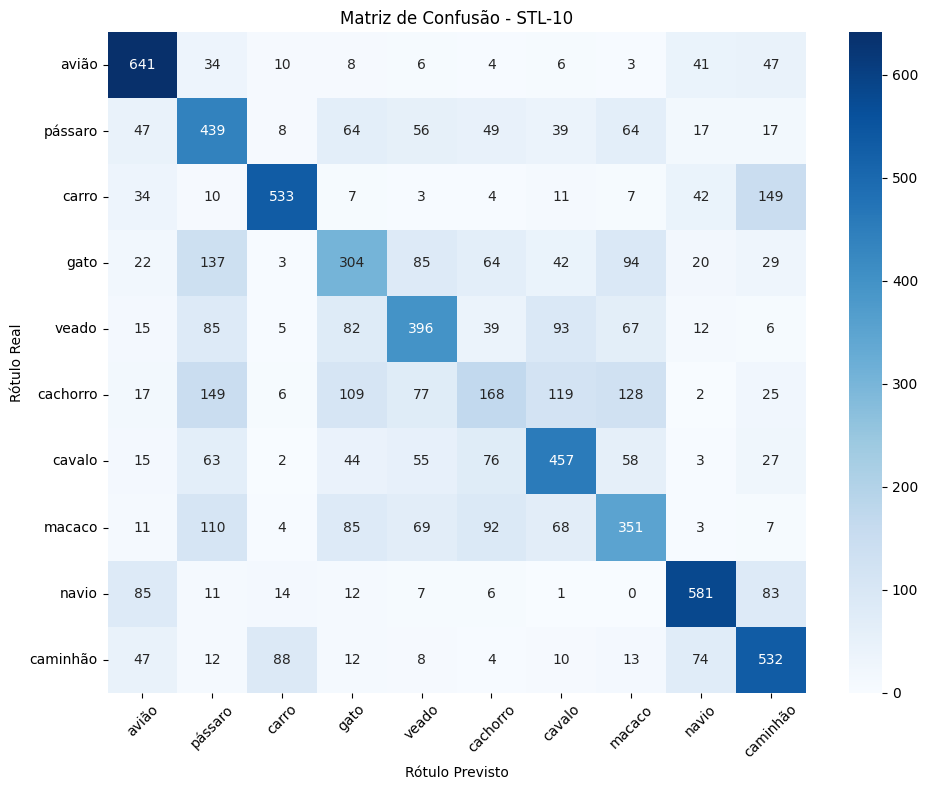

In [18]:
# --- Adaptação para Matriz de Confusão no STL-10 ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Coleta as previsões e os rótulos reais do pipeline de teste
y_true = []
y_pred_classes = []

# Iteramos sobre o dataset de teste para pegar as imagens e as labels reais
for imagens, labels in test_data:
    preds = modelo_lia.predict(imagens, verbose=0)
    y_pred_classes.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# 2. Geração da matriz de confusão
cm = confusion_matrix(y_true, y_pred_classes)

# 3. Impressão Visual
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nomes_classes,
            yticklabels=nomes_classes)

plt.title('Matriz de Confusão - STL-10')
plt.xlabel('Rótulo Previsto')
plt.ylabel('Rótulo Real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
# Carrega uma nova imagem
nova_imagem = Image.open("F-117-1024x576.jpg")

In [31]:

# Dimensões da imagem (em pixels)
nova_imagem.size

# Obtém largura e altura da imagem
largura = nova_imagem.width
altura = nova_imagem.height

In [32]:
print("A largura da imagem é: ", largura)
print("A altura da imagem é: ", altura)

A largura da imagem é:  1024
A altura da imagem é:  576


In [33]:
# Redimensiona para 96x96 pixels
nova_imagem = nova_imagem.resize((96, 96))



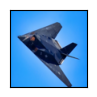

In [34]:
# Exibir a imagem
plt.figure(figsize = (1,1))
plt.imshow(nova_imagem)
plt.xticks([])
plt.yticks([])
plt.show()


In [35]:
# Converte a imagem para um array NumPy e normaliza
nova_imagem_array = np.array(nova_imagem) / 255.0

In [36]:
# Expande a dimensão do array para que ele tenha o formato (1, 32, 32, 3)
nova_imagem_array = np.expand_dims(nova_imagem_array, axis = 0)


In [37]:

# Previsões
previsoes = modelo_lia.predict(nova_imagem_array)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [38]:
print(previsoes)

[[9.7955668e-01 2.0443283e-02 1.7630874e-32 4.9672039e-30 4.1219048e-21
  1.4504043e-31 1.8903507e-37 5.2541662e-29 3.8364624e-11 1.2871970e-20]]


In [39]:
# Obtém a classe com maior probabilidade e o nome da classe
classe_prevista = np.argmax(previsoes)
nome_classe_prevista = nomes_classes[classe_prevista]



In [40]:
print("A nova imagem foi classificada como:", nome_classe_prevista)

A nova imagem foi classificada como: avião
